In [10]:
# %%
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, f1_score, accuracy_score
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer
import warnings
warnings.filterwarnings('ignore')

In [11]:
def compute_scatter_matrices(X, y):
    '''Computes the scatter matrices for a given dataset.'''

    classes = np.unique(y)
    n_features = X.shape[1]

    mu = np.mean(X, axis=0)

    W = np.zeros((n_features, n_features))
    B = np.zeros((n_features, n_features))

    for c in classes:
        Xc = X[y == c]

        mu_c = np.mean(Xc, axis=0)

        # Within class scatter
        diff = Xc - mu_c
        W += diff.T @ diff

        # Between class scatter
        n_c = Xc.shape[0]
        mean_diff = (mu_c - mu).reshape(-1, 1)
        B += n_c * (mean_diff @ mean_diff.T)

    W += np.eye(n_features) * 1e-6  # Regularization to ensure W is invertible

    return W, B

In [12]:
def compute_dann_transform(W, B, eps=1e-3):
    ''' Computes the DANN transformation matrix.'''

    eigvals, eigvecs = np.linalg.eigh(W)

    W_inv_sqrt = eigvecs @ np.diag(1/(np.sqrt(eigvals) + 1e-8)) @ eigvecs.T

    B_star = W_inv_sqrt @ B @ W_inv_sqrt

    sigma = W_inv_sqrt @ (B_star + eps*np.eye(W.shape[0])) @ W_inv_sqrt

    # Cholesky decomposition for L
    L = np.linalg.cholesky(sigma)

    return L

In [13]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.neighbors import NearestNeighbors


class LocalDANN(BaseEstimator, ClassifierMixin):

    def __init__(self, n_neighbors=5, k0=50, eps=1e-3):
        self.n_neighbors = n_neighbors
        self.k0 = k0
        self.eps = eps

    def fit(self, X, y):
        self.X = np.asarray(X)
        self.y = np.asarray(y)

        # Precompute Euclidean neighbor structure
        self.nbrs = NearestNeighbors(n_neighbors=self.k0, metric='euclidean')
        self.nbrs.fit(self.X)

        return self

    def _compute_scatter(self, Xn, yn):
        classes = np.unique(yn)
        d = Xn.shape[1]

        mu = np.mean(Xn, axis=0)

        W = np.zeros((d, d))
        B = np.zeros((d, d))

        for c in classes:
            Xc = Xn[yn == c]
            mu_c = np.mean(Xc, axis=0)

            diff = Xc - mu_c
            W += diff.T @ diff

            n_c = Xc.shape[0]
            md = (mu_c - mu).reshape(-1, 1)
            B += n_c * (md @ md.T)

        # regularization
        W += 1e-6 * np.eye(d)

        return W, B

    def _compute_metric(self, W, B):

        eigvals, eigvecs = np.linalg.eigh(W)
        W_inv_sqrt = eigvecs @ np.diag(1/np.sqrt(eigvals + 1e-10)) @ eigvecs.T

        B_star = W_inv_sqrt @ B @ W_inv_sqrt

        Sigma = W_inv_sqrt @ (B_star + self.eps * np.eye(W.shape[0])) @ W_inv_sqrt

        return Sigma

    def predict(self, Xq):

        Xq = np.asarray(Xq)
        preds = []

        for x in Xq:

            # Step 1: get k0 neighbors (Euclidean)
            _, idx = self.nbrs.kneighbors([x])
            # print("Got Neighbors")
            idx = idx[0]

            Xn = self.X[idx]
            yn = self.y[idx]

            # Step 2: local scatter
            W, B = self._compute_scatter(Xn, yn)
            # print("Computed Scatter")

            # Step 3: local metric
            Sigma = self._compute_metric(W, B)
            # print("Computed Sigma")
            # Step 4: compute distances (Mahalanobis)
            diff = self.X - x
            dists = np.sum((diff @ Sigma) * diff, axis=1)

            # Step 5: final KNN
            nn_idx = np.argsort(dists)[:self.n_neighbors]
            votes = self.y[nn_idx]

            pred = np.bincount(votes).argmax()
            preds.append(pred)
            # print("Completed prediction")

        return np.array(preds)

In [14]:
# %%
# ─────────────────────────────────────────────────────────────────────────────
# Theoretical Risk Functions  (Cover & Hart 1967 / Dist-KNN framework)
# ─────────────────────────────────────────────────────────────────────────────

def compute_r_star_x(model, X_query: pd.DataFrame) -> np.ndarray:
    """
    Conditional Bayes risk r*(x) at each query point x.

    For an M-class problem:
        r*(x) = 1 - max_c { q̂_c(x) }

    i.e. 1 minus the highest posterior class probability.
    This equals min(q̂₁, q̂₂) in the binary case.

    Parameters
    ----------
    model     : fitted GridSearchCV wrapping a KNeighborsClassifier (dictionary containing dist and prob model)
    X_query   : query points  (n_samples × n_features)

    Returns
    -------
    r_star : ndarray of shape (n_samples,)
    """
    prob_model = model['prob_model']
    q_hat = prob_model.predict_proba(X_query)          # (n_samples, n_classes)
    r_star = 1.0 - q_hat.max(axis=1)              # scalar per query point
    return r_star


def compute_R_star(model, X_query: pd.DataFrame) -> float:
    """
    Expected Bayes risk R* = E[r*(x)] for one machine,
    approximated by the sample mean over X_query.

    Parameters
    ----------
    model     : fitted GridSearchCV
    X_query   : held-out query points

    Returns
    -------
    R_star : float
    """
    return float(compute_r_star_x(model, X_query).mean())


def compute_mu_hat(model, X: pd.DataFrame) -> np.ndarray:
    """
    Proxy for μ(x): the model's predicted class probability vector at each point.
    Works for any number of classes — returns the full (n_samples, n_classes) matrix
    so that bias can be computed per class and then averaged into a scalar norm.

    Parameters
    ----------
    model : fitted GridSearchCV (dictionary for prob_model and dist_model)
    X     : feature matrix

    Returns
    -------
    mu_hat : ndarray of shape (n_samples, n_classes)
    """
    prob_model = model['prob_model']
    return prob_model.predict_proba(X)   # (n_samples, n_classes)


def compute_bias_vector(
    model,
    X_query: pd.DataFrame,
    K_i: int,
) -> np.ndarray:
    """
    Local bias for machine i, generalised to any number of classes:
        Bᵢ(x) = ‖μ(x) - (1/Kᵢ) Σⱼ μ(xᵢ,ⱼ)‖₂

    μ(x) is the full predicted class-probability vector (n_classes,).
    The per-class difference is averaged across classes via the L2 norm
    to produce a single scalar bias per query point, which is what the
    Dist-KNN covariance matrix C requires.

    Parameters
    ----------
    model   : fitted GridSearchCV (KNN inside)
    X_query : query points  (n_samples × n_features)
    K_i     : number of neighbours used by this machine

    Returns
    -------
    B_i : ndarray of shape (n_samples,)  — one scalar bias per query point
    """
    dist_model = model['dist_model']
    knn: KNeighborsClassifier = dist_model.best_estimator_

    # μ(x) — full probability vector at each query point: (n_samples, n_classes)
    mu_x = compute_mu_hat(model, X_query)

    # Retrieve the K_i nearest training-set neighbours for each query point
    distances, indices = knn.kneighbors(X_query, n_neighbors=K_i)

    # μ̂ at every training point: (n_train, n_classes)
    X_train_arr = knn._fit_X
    X_train_df  = pd.DataFrame(X_train_arr, columns=X_query.columns)
    mu_train    = compute_mu_hat(model, X_train_df)   # (n_train, n_classes)

    # Average μ over the K_i neighbours: indices is (n_samples, K_i)
    # mu_train[indices] → (n_samples, K_i, n_classes)
    mu_neighbour_means = mu_train[indices].mean(axis=1)  # (n_samples, n_classes)

    # Per-class difference, collapsed to a scalar via L2 norm — works for any n_classes
    B_i = np.linalg.norm(mu_x - mu_neighbour_means, axis=1)  # (n_samples,)
    return B_i


print("Theoretical risk functions defined.")

Theoretical risk functions defined.


In [15]:
def create_models(server_datasets):

    best_neighbors = []
    best_f1_scores = []
    model_instance_list = []
    dataset_sizes = []
        
    for df_train, df_test in (server_datasets):
        params1 = {"n_neighbors": np.arange(3, 51, 2)}
        knn = KNeighborsClassifier()
        model1 = GridSearchCV(knn, params1, scoring='f1_macro', cv=2, n_jobs=-1)
        # params2 = {"n_estimators": np.array([50, 100, 150, 200]), "max_depth": np.array([3, 5, 8, 10, 15])}
        # random_forests = RandomForestClassifier()
        # model2 = GridSearchCV(random_forests, params2, scoring='f1_macro', cv=2, n_jobs=-1)
        
        X_s_train = df_train.drop(['y'], axis=1).values
        y_s_train = df_train['y'].values
        X_s_test = df_test.drop(['y'], axis=1).values
        y_s_test = df_test['y'].values

        
        model1.fit(X_s_train, y_s_train)
        # model2.fit(X_s_train, y_s_train)
        y_pred = model1.predict(X_s_test)
        
        best_neighbors.append(model1.best_params_['n_neighbors'])
        best_f1_scores.append(f1_score(y_s_test, y_pred, average='macro'))
        model_instance_list.append({
            'dist_model': model1,
            'prob_model': model1
        })
        
        # # Compute median distances (possible logical flaw)
        # nbrs = model.best_estimator_
        # distances, indices = nbrs.kneighbors(X_s_train)
        # distances_no_self = distances[:, 1:]
        # median_neighbor_distance.append(np.median(distances_no_self))
        
        dataset_sizes.append(df_train.shape[0])

    return (best_neighbors, best_f1_scores, model_instance_list, dataset_sizes)

In [16]:
class ModelPerformanceAnalyzer:
    def __init__(self, models, model_names = None): # models : {dist_model: (knn model for neighbor), prob_model: (rf model for probabilities)}
        self.models = models
        self.model_names = model_names or [f"Model_{i}" for i in range(len(models))]
        self.performance_df = None
    
    def analyze_models(self, X_unseen, y_unseen):
        results = []
        for i, (model, name) in enumerate(zip(self.models, self.model_names)):
            
            model_metrics = self._analyze_single_model(
                model, name, i, X_unseen, y_unseen
            )
            results.append(model_metrics)
        
        self.performance_df = pd.DataFrame(results)
        return self.performance_df
    
    
    def _analyze_single_model(self, model, name, index, X_unseen, y_unseen):

        #Predictions and probabilities
        y_pred = model['prob_model'].predict(X_unseen)
        y_proba = model['prob_model'].predict_proba(X_unseen)

        #Distance metrics

        metrics = {
            'model_name': name,
            'model_index': index,
            'f1_score': f1_score(y_unseen, y_pred, average='macro'),
            'classification_probabilities': y_proba.tolist()
        }

        distance_metrics = self._calculate_distance_metrics(model['dist_model'], X_unseen)
        metrics.update(distance_metrics)
        return metrics


    def _calculate_distance_metrics(self, model, X_unseen):
        """Calculate various distance-based metrics."""
        try:
            nbrs = model.best_estimator_
            
            # Calculate distance matrix
            distances, indices = nbrs.kneighbors(X_unseen)
            distances_no_self = distances
            
            # Various distance statistics
            point_medians = np.median(distances_no_self, axis=1)
            point_means = np.mean(distances_no_self, axis=1)
            point_mins = np.min(distances_no_self, axis=1)
            point_maxs = np.max(distances_no_self, axis=1)
            
            return {
                'median_distance_all_points': np.median(point_medians),
                'mean_distance_all_points': np.mean(point_means),
                'min_distance_all_points': np.min(point_mins),
                'max_distance_all_points': np.max(point_maxs),
                'distance_std': np.std(distances_no_self),
            }
        except Exception as e:
            warnings.warn(f"Distance calculation failed for model: {e}")
            return {
                'median_distance_all_points': np.nan,
                'mean_distance_all_points': np.nan,
                'min_distance_all_points': np.nan,
                'max_distance_all_points': np.nan,
                'distance_std': np.nan,
            }
    def get_probability_matrix(self, model_index):
        """Get probability matrix for a specific model as numpy array."""
        if self.performance_df is not None:
            return np.array(self.performance_df.loc[model_index, 'classification_probabilities'])
        return None
    
    def get_all_probabilities(self):
        """Get all probability matrices as a 3D array (models x samples x classes)."""
        if self.performance_df is not None:
            return np.array([np.array(probs) for probs in self.performance_df['classification_probabilities']])
        return None

In [17]:
def run_distributed_knn_simulation(data_train, data_test, n_simulations=10, n_servers=100, test_size=0.2):
    """
    Optimized version using ModelPerformanceAnalyzer for probability extraction
    """
    import scipy.linalg as la

    simulation_results = []
    all_medians = []
    all_means = []

    for sim in range(n_simulations):
        print(f"Running simulation {sim+1}/{n_simulations}")

        # 1. Split data
        X_train_full   = data_train.drop(['y'], axis=1)
        y_train_full   = data_train['y']
        X_test_heldout = data_test.drop(['y'], axis=1)
        y_test_heldout = data_test['y']

        # 2. Generate server datasets
        def generate_server_datasets(train_pool, test_pool, n_servers=100,
                                     min_samples=1000, max_samples=5000):
            server_datasets = []
            X_train_pool    = train_pool.drop(columns=['y'])
            y_train_pool    = train_pool['y']
            X_test_pool     = test_pool.drop(columns=['y'])
            y_test_pool     = test_pool['y']

            for seed in range(n_servers):
                train_size = np.random.randint(min_samples, max_samples)
                sss_train  = StratifiedShuffleSplit(
                    n_splits=1, train_size=train_size, random_state=seed
                )
                train_idx, _ = next(sss_train.split(X_train_pool, y_train_pool))
                server_train  = train_pool.iloc[train_idx]

                test_size_s = int(0.3 * train_size)
                sss_test    = StratifiedShuffleSplit(
                    n_splits=1, train_size=test_size_s, random_state=seed
                )
                test_idx, _ = next(sss_test.split(X_test_pool, y_test_pool))
                server_test  = test_pool.iloc[test_idx]

                server_datasets.append((server_train, server_test))

            return server_datasets

        train_pool_df = pd.concat([X_train_full, y_train_full], axis=1)
        test_pool_df  = pd.concat([X_test_heldout, y_test_heldout], axis=1)

        server_datasets = generate_server_datasets(
            train_pool_df, test_pool_df, n_servers=n_servers
        )

        # 3. Train models
        best_neighbors, best_f1_scores, model_instance_list, dataset_sizes = create_models(server_datasets)

        metrics_df = pd.DataFrame({
            'optimal_k_value': best_neighbors,
            'best_f1_scores' : best_f1_scores,
            'model_instance' : model_instance_list,
            'dataset_size'   : dataset_sizes
        })
        metrics_df = metrics_df[metrics_df['best_f1_scores'] != 0].reset_index(drop=True)

        # 4. Test on held-out data
        n_test_samples = min(500, len(X_test_heldout))
        test_indices   = np.random.choice(len(X_test_heldout), size=n_test_samples, replace=False)
        X_test_samples = X_test_heldout.iloc[test_indices]
        y_test_true    = y_test_heldout.iloc[test_indices]

        # Use ModelPerformanceAnalyzer to get all metrics and probabilities
        analyzer    = ModelPerformanceAnalyzer(metrics_df['model_instance'].tolist())
        analysis_df = analyzer.analyze_models(X_test_samples, y_test_true)

        # Merge results
        metrics_df = metrics_df.merge(
            analysis_df[['model_index', 'median_distance_all_points', 'mean_distance_all_points']],
            left_index=True,
            right_on='model_index'
        ).reset_index(drop=True)

        all_medians.extend(metrics_df['median_distance_all_points'].tolist())
        all_means.extend(metrics_df['mean_distance_all_points'].tolist())

        # 5. Define scoring functions
        def arctan_score(distance, df):
            min_d = df['median_distance_all_points'].min()
            max_d = df['median_distance_all_points'].max()
            return 0.5 + (np.arctan(((max_d + min_d)/2) - distance) / np.pi)

        def tanh_score(distance, df):
            min_d = df['median_distance_all_points'].min()
            max_d = df['median_distance_all_points'].max()
            return 0.5 + 0.5 * (np.tanh(((max_d + min_d)/2) - distance))

        def sigmoid_score(distance, df):
            min_d = df['median_distance_all_points'].min()
            max_d = df['median_distance_all_points'].max()
            return 1 / (1 + 2 * np.exp(((max_d + min_d)/2) - distance))

        def relu_score(distance, df):
            mean      = df['mean_distance_all_points'].mean()
            deviation = df['mean_distance_all_points'].std()
            score     = mean + 2 * deviation - distance
            return score if score > 0 else 0

        metrics_df['arctan_score']  = metrics_df['median_distance_all_points'].apply(lambda x: arctan_score(x, metrics_df))
        metrics_df['tanh_score']    = metrics_df['median_distance_all_points'].apply(lambda x: tanh_score(x, metrics_df))
        metrics_df['sigmoid_score'] = metrics_df['median_distance_all_points'].apply(lambda x: sigmoid_score(x, metrics_df))
        metrics_df['relu_score']    = metrics_df['mean_distance_all_points'].apply(lambda x: relu_score(x, metrics_df))

        # 6. Extract probabilities
        probability_list = []
        for i in range(len(X_test_samples)):
            point_probs = []
            for model_idx in range(len(metrics_df)):
                model_probs = analyzer.get_probability_matrix(model_idx)
                point_probs.append(model_probs[i])
            probability_list.append(point_probs)
        probability_list = np.array(probability_list)   # (n_query, M, n_classes)

        # 7. Theoretical risk quantities — computed BEFORE aggregation so W* can be used
        sim_models = metrics_df['model_instance'].tolist()
        sim_K_list = metrics_df['optimal_k_value'].tolist()
        M_sim      = len(sim_models)
        n_q        = len(X_test_samples)

        def _r_star_x(model, X):
            """r*(x) = 1 - max_c q̂_c(x)  — works for any number of classes."""
            return 1.0 - model['prob_model'].predict_proba(X).max(axis=1)

        def _bias_scalar_ols(model, X_query, K_i):
            """
            Paper-exact scalar spatial bias bᵢ for server i (Section V, Theorem 2).

            Steps (averaged over all query points xq):
              1. For each xq, retrieve its K_i local neighbours from this server's KNN.
              2. Build centred design matrix Xᵢ ∈ R^{K_i × d} and centred one-hot
                 probability target ỹᵢ ∈ R^{K_i} (majority class probability, centred).
              3. Solve OLS for the local gradient: gᵢ = (XᵢᵀXᵢ)⁻¹ Xᵢᵀ ỹᵢ
              4. Compute the median displacement vector dᵢ ∈ R^d — the feature-space
                 displacement from xq to the neighbour at the median distance.
              5. bᵢ(xq) = gᵢ · dᵢ    (dot product, scalar)
            Returns the mean of bᵢ(xq) over all query points as one scalar per server,
            matching the O(1) transmission requirement in the paper.
            """
            knn        = model['dist_model'].best_estimator_
            prob_model = model['prob_model']
            X_train    = knn._fit_X                             # (n_train, d)
            X_q_arr    = X_query.values                         # (n_q, d)

            # One-hot encoded class probabilities for every training point → target proxy
            # Shape: (n_train, n_classes); we use the max-class column as the scalar target
            X_train_df  = pd.DataFrame(X_train, columns=X_query.columns)
            p_train     = prob_model.predict_proba(X_train_df)  # (n_train, n_classes)

            distances, indices = knn.kneighbors(X_query, n_neighbors=K_i)
            # distances: (n_q, K_i), indices: (n_q, K_i)

            b_scalars = []
            for q_idx in range(n_q):
                xq       = X_q_arr[q_idx]                       # (d,)
                nbr_idx  = indices[q_idx]                        # (K_i,)
                nbr_dist = distances[q_idx]                      # (K_i,)

                X_nbr    = X_train[nbr_idx]                      # (K_i, d)
                p_nbr    = p_train[nbr_idx]                      # (K_i, n_classes)

                # Use the probability of the predicted class as the scalar target
                pred_class  = np.argmax(p_nbr.mean(axis=0))
                p_target    = p_nbr[:, pred_class]               # (K_i,)

                # Centre design matrix and target (OLS on local neighbourhood)
                X_mean   = X_nbr.mean(axis=0)
                p_mean   = p_target.mean()
                Xi_c     = X_nbr - X_mean                        # (K_i, d)
                yi_c     = p_target - p_mean                     # (K_i,)

                # OLS gradient: gᵢ = (XᵢᵀXᵢ + λI)⁻¹ Xᵢᵀ ỹᵢ  (ridge for stability)
                XtX      = Xi_c.T @ Xi_c + 1e-6 * np.eye(Xi_c.shape[1])
                Xty      = Xi_c.T @ yi_c
                g_i      = np.linalg.solve(XtX, Xty)            # (d,)

                # Median displacement vector dᵢ: displacement of the median-distance neighbour
                med_idx  = np.argmin(np.abs(nbr_dist - np.median(nbr_dist)))
                d_i      = X_nbr[med_idx] - xq                  # (d,)  signed displacement

                b_scalars.append(float(g_i @ d_i))

            return float(np.mean(b_scalars))   # single scalar per server

        # r*(x) and R* per server
        r_star_x_list, R_star_list = [], []
        for model in sim_models:
            r_x = _r_star_x(model, X_test_samples)
            r_star_x_list.append(r_x)
            R_star_list.append(float(r_x.mean()))

        r_star_matrix = np.stack(r_star_x_list, axis=0)   # (M, n_query)
        R_star_vec    = np.array(R_star_list)              # (M,)

        # bᵢ — paper-exact OLS scalar bias using median displacement (one scalar per server)
        # This is the quantity the paper says each client transmits (O(1) communication).
        b_vec = np.array([
            _bias_scalar_ols(model, X_test_samples, K_i)
            for model, K_i in zip(sim_models, sim_K_list)
        ])  # (M,)

        # C = b bᵀ — rank-1 outer product as defined in Theorem 2 of the paper
        C = np.outer(b_vec, b_vec)                         # (M, M)

        # V diagonal: Vᵢᵢ = R*ᵢ / Kᵢ
        V = np.diag(R_star_vec / np.array(sim_K_list, dtype=float))

        # Optimal W* via Sherman-Morrison (paper Section V, closed form)
        #   W* = (V+C)⁻¹ 1 / (1ᵀ (V+C)⁻¹ 1)
        # Pre-compute scalar sums for the Sherman-Morrison expansion
        K_vec  = np.array(sim_K_list, dtype=float)
        V_inv_diag = K_vec / R_star_vec                    # diagonal of V⁻¹
        S11    = np.sum(V_inv_diag)                        # 1ᵀ V⁻¹ 1
        Sb1    = float(b_vec @ V_inv_diag)                 # bᵀ V⁻¹ 1
        Sbb    = float(b_vec @ (V_inv_diag * b_vec))       # bᵀ V⁻¹ b

        denom_sm = S11 - (Sb1 ** 2) / (1.0 + Sbb)        # scalar denominator
        # Numerator: w*ᵢ ∝ (Kᵢ/R*ᵢ) · (1 − bᵢ · Sb1/(1+Sbb))
        num_vec  = V_inv_diag * (1.0 - b_vec * Sb1 / (1.0 + Sbb))
        W_star   = num_vec / denom_sm                      # (M,) — sums to 1 by construction

        # Clamp any numerically negative weights to zero and renormalise
        W_star   = np.clip(W_star, 0.0, None)
        W_star  /= W_star.sum()

        # Optimal R = R* + 1 / (1ᵀ (V+C)⁻¹ 1)  (Sherman-Morrison form)
        R_global_mean = float(R_star_vec.mean())
        R_optimal     = R_global_mean + 1.0 / denom_sm

        # Keep B_matrix for visualisation (store per-server bias scalar broadcast to n_query shape)
        B_matrix = b_vec[:, None] * np.ones((M_sim, n_q))  # (M, n_query) — constant per server

        # 8. Weighted predictions — approaches 1–5 (heuristic) + approach 6 (optimal W*)
        approaches = {
            'approach_1': 'arctan_score',
            'approach_2': 'dataset_size',
            'approach_3': 'tanh_score',
            'approach_4': 'sigmoid_score',
            'approach_5': 'relu_score'
        }

        approach_preds = {}
        for approach_name, weight_col in approaches.items():
            weights = metrics_df[weight_col].values
            weighted_results = []
            for probability in probability_list:
                weighted = probability * weights.reshape(-1, 1)
                weighted_results.append(weighted.sum(axis=0) / weights.sum())
            approach_preds[approach_name] = np.array([np.argmax(p) for p in weighted_results])

        # Approach 6 — optimal W* (already sums to 1, no normalisation needed)
        weighted_results_wstar = []
        for probability in probability_list:
            weighted = probability * W_star.reshape(-1, 1)   # (M, n_classes)
            weighted_results_wstar.append(weighted.sum(axis=0))
        approach_preds['approach_6'] = np.array([np.argmax(p) for p in weighted_results_wstar])

        # 9. Calculate metrics for all approaches
        sim_result = {'simulation': sim}
        for approach_name, preds in approach_preds.items():
            sim_result[f'{approach_name}_f1']  = f1_score(y_test_true, preds, average='macro')
            sim_result[f'{approach_name}_acc'] = accuracy_score(y_test_true, preds)

        sim_result.update({
            'n_servers'          : len(metrics_df),
            'avg_dataset_size'   : metrics_df['dataset_size'].mean(),
            'avg_median_distance': metrics_df['median_distance_all_points'].mean(),
            # Theoretical quantities
            'r_star_per_server'  : R_star_list,
            'r_star_x_matrix'    : r_star_matrix.tolist(),
            'bias_matrix'        : B_matrix.tolist(),
            'C_matrix'           : C.tolist(),
            'V_diag'             : np.diag(V).tolist(),
            'W_star'             : W_star.tolist(),
            'mean_R_star'        : R_global_mean,
            'min_R_star'         : float(R_star_vec.min()),
            'max_R_star'         : float(R_star_vec.max()),
            'optimal_R'          : R_optimal,
        })

        simulation_results.append(sim_result)

    results_df = pd.DataFrame(simulation_results)
    return results_df, all_medians, all_means

In [18]:
# %%
# Load your data
# data_train = pd.read_csv('/kaggle/input/datasets/abhirajraje/oelp-dataset/adult_preprocessed_train.csv')
# data_test = pd.read_csv('/kaggle/input/datasets/abhirajraje/oelp-dataset/adult_preprocessed_test.csv')

data_train = pd.read_csv('../data/adult_preprocessed_train.csv')
data_test = pd.read_csv('../data/adult_preprocessed_test.csv')

# Run multiple simulations
results_df, all_medians, all_means = run_distributed_knn_simulation(data_train, data_test, n_simulations=5, n_servers=10)

Running simulation 1/5
Running simulation 2/5
Running simulation 3/5
Running simulation 4/5
Running simulation 5/5


In [19]:
print(results_df)

   simulation  approach_1_f1  approach_1_acc  approach_2_f1  approach_2_acc  \
0           0       0.720708           0.826       0.718481           0.826   
1           1       0.769059           0.842       0.767525           0.842   
2           2       0.772072           0.858       0.759584           0.852   
3           3       0.781909           0.862       0.782873           0.860   
4           4       0.750303           0.832       0.749869           0.830   

   approach_3_f1  approach_3_acc  approach_4_f1  approach_4_acc  \
0       0.720708           0.826       0.722824           0.828   
1       0.769059           0.842       0.763212           0.838   
2       0.769768           0.856       0.769768           0.856   
3       0.781909           0.862       0.769266           0.854   
4       0.750303           0.832       0.746079           0.828   

   approach_5_f1  ...                                  r_star_per_server  \
0       0.731337  ...  [0.17441379310344826, 0

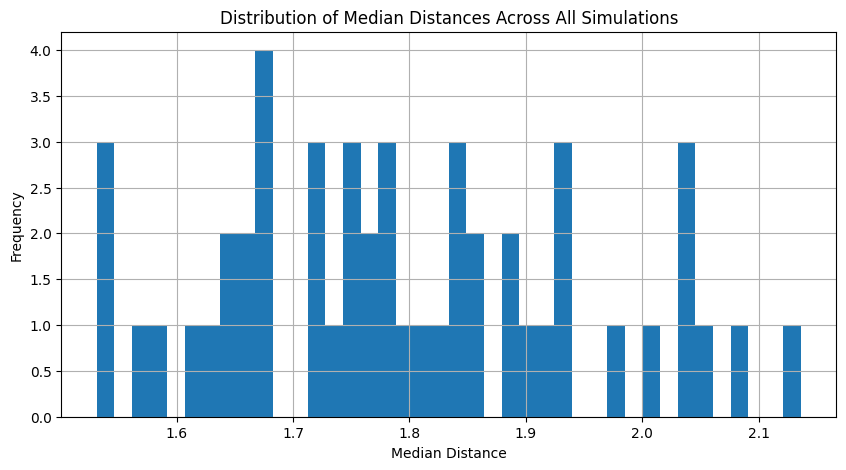

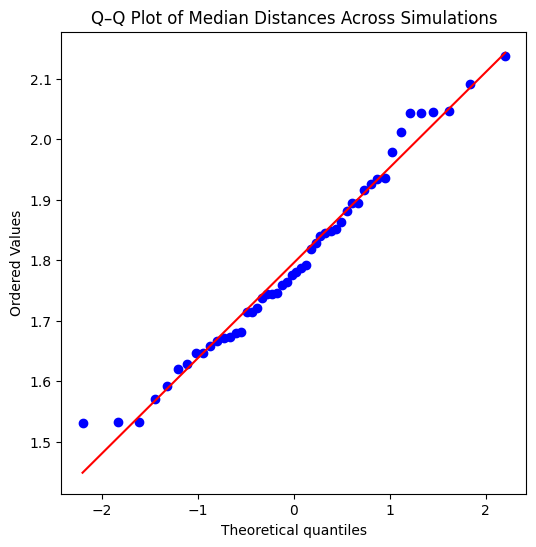

In [20]:
import scipy.stats as stats

plt.figure(figsize=(10, 5))
plt.hist(all_medians, bins=40)
plt.title('Distribution of Median Distances Across All Simulations')
plt.xlabel('Median Distance')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 6))
stats.probplot(all_medians, dist="norm", plot=plt)
plt.title('Q–Q Plot of Median Distances Across Simulations')
plt.show()

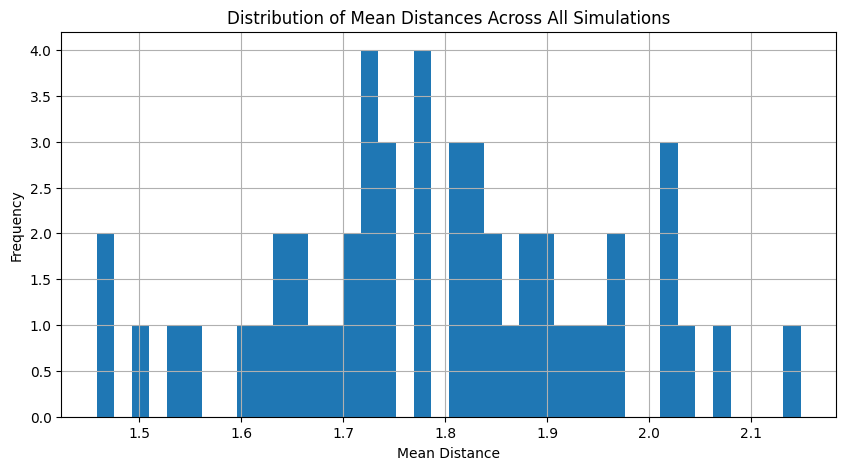

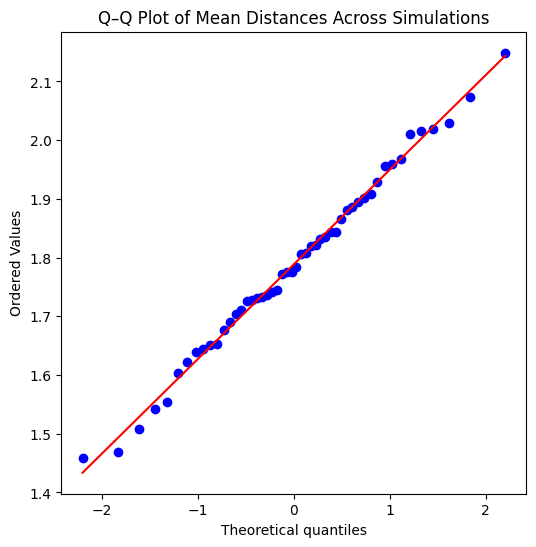

In [21]:
import scipy.stats as stats

plt.figure(figsize=(10, 5))
plt.hist(all_means, bins=40)
plt.title('Distribution of Mean Distances Across All Simulations')
plt.xlabel('Mean Distance')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

plt.figure(figsize=(6, 6))
stats.probplot(all_means, dist="norm", plot=plt)
plt.title('Q–Q Plot of Mean Distances Across Simulations')
plt.show()

In [22]:
# Find the best KNN on overall data
X_train = data_train.drop(['y'], axis=1)
y_train = data_train['y']
X_test = data_test.drop(['y'], axis=1)
y_test = data_test['y']


params1 = {"n_neighbors": np.arange(3, 31, 2)}
knn = KNeighborsClassifier()
model = GridSearchCV(knn, params1, scoring='f1_macro', cv=2, n_jobs=-1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

buffer_model = {"dist_model": model, "prob_model" : model} # Just there because compute_R_star accepts a dictionary

R_star_global_model = compute_R_star(buffer_model, X_test)
k_global_model = model.best_params_['n_neighbors']

V_global_model = R_star_global_model / k_global_model
print(classification_report(y_test, y_pred))
print(f"Best Params: {model.best_params_}")
print(f"Best F1 Score: {f1_score(y_test, y_pred, average='macro')}")

benchmark_f1 = f1_score(y_test, y_pred, average='macro')

              precision    recall  f1-score   support

           0       0.88      0.92      0.90     12435
           1       0.71      0.61      0.66      3846

    accuracy                           0.85     16281
   macro avg       0.80      0.77      0.78     16281
weighted avg       0.84      0.85      0.84     16281

Best Params: {'n_neighbors': np.int64(19)}
Best F1 Score: 0.7789630925978328


In [23]:
# %%
# Analyze results
print("Simulation Results Summary:")
print("=" * 50)
print(f"Number of simulations: {len(results_df)}")
print(f"Average F1 Scores:")
print(f"Approach 1 (Arctan): {results_df['approach_1_f1'].mean():.4f} ± {results_df['approach_1_f1'].std():.4f}")
print(f"Approach 2 (Size):   {results_df['approach_2_f1'].mean():.4f} ± {results_df['approach_2_f1'].std():.4f}")
print(f"Approach 3 (Tanh):   {results_df['approach_3_f1'].mean():.4f} ± {results_df['approach_3_f1'].std():.4f}")
print(f"Approach 4 (Sigmoid):   {results_df['approach_4_f1'].mean():.4f} ± {results_df['approach_4_f1'].std():.4f}")
print(f"Approach 5 (ReLU):   {results_df['approach_5_f1'].mean():.4f} ± {results_df['approach_5_f1'].std():.4f}")
print(f"Approach 6 (W*):   {results_df['approach_6_f1'].mean():.4f} ± {results_df['approach_6_f1'].std():.4f}")


Simulation Results Summary:
Number of simulations: 5
Average F1 Scores:
Approach 1 (Arctan): 0.7588 ± 0.0242
Approach 2 (Size):   0.7557 ± 0.0240
Approach 3 (Tanh):   0.7583 ± 0.0239
Approach 4 (Sigmoid):   0.7542 ± 0.0200
Approach 5 (ReLU):   0.7595 ± 0.0213
Approach 6 (W*):   0.7504 ± 0.0183


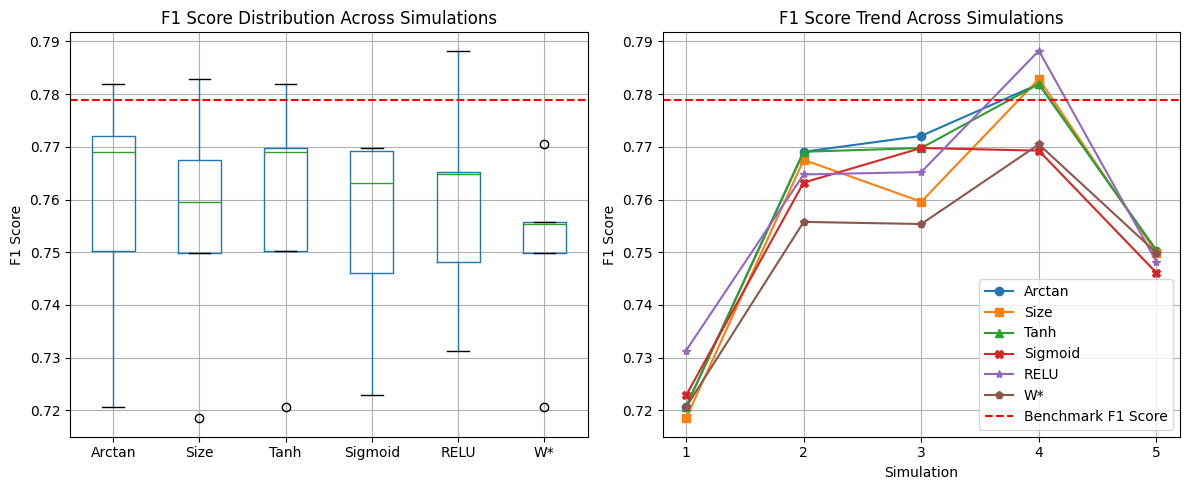

In [24]:
# %%
# Visualization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
results_df[['approach_1_f1', 'approach_2_f1', 'approach_3_f1', 'approach_4_f1', 'approach_5_f1', 'approach_6_f1']].boxplot()
plt.title('F1 Score Distribution Across Simulations')
plt.ylabel('F1 Score')
plt.axhline(y=benchmark_f1, color='r', linestyle='--', label='Benchmark F1 Score')
plt.xticks([1, 2, 3, 4, 5, 6], ['Arctan', 'Size', 'Tanh', 'Sigmoid', 'RELU', 'W*'])

plt.subplot(1, 2, 2)
plt.plot(results_df['approach_1_f1'], label='Arctan', marker='o')
plt.plot(results_df['approach_2_f1'], label='Size', marker='s')
plt.plot(results_df['approach_3_f1'], label='Tanh', marker='^')
plt.plot(results_df['approach_4_f1'], label='Sigmoid', marker='X')
plt.plot(results_df['approach_5_f1'], label='RELU', marker='*')
plt.plot(results_df['approach_6_f1'], label='W*', marker='p')
plt.axhline(y=benchmark_f1, color='r', linestyle='--', label='Benchmark F1 Score')
plt.xticks(np.arange(len(results_df)), np.arange(1, len(results_df)+1))
plt.xlabel('Simulation')
plt.ylabel('F1 Score')
plt.title('F1 Score Trend Across Simulations')
plt.legend()
plt.grid(True)

# plt.savefig('f1_score_trends_std_normal.png')

plt.tight_layout()
plt.show()


In [25]:
# %%
# Statistical significance testing
from scipy.stats import ttest_rel

# Pairwise t-tests
t_stat_1_2, p_val_1_2 = ttest_rel(results_df['approach_1_f1'], results_df['approach_2_f1'])
t_stat_1_3, p_val_1_3 = ttest_rel(results_df['approach_1_f1'], results_df['approach_3_f1'])
t_stat_2_3, p_val_2_3 = ttest_rel(results_df['approach_2_f1'], results_df['approach_3_f1'])
t_stat_2_4, p_val_2_4 = ttest_rel(results_df['approach_2_f1'], results_df['approach_4_f1'])
t_stat_3_4, p_val_3_4 = ttest_rel(results_df['approach_3_f1'], results_df['approach_4_f1'])
t_stat_1_4, p_val_1_4 = ttest_rel(results_df['approach_1_f1'], results_df['approach_4_f1'])

print("\nStatistical Significance (paired t-tests):")
print(f"Arctan vs Size: p-value = {p_val_1_2:.4f}")
print(f"Arctan vs Tanh: p-value = {p_val_1_3:.4f}")
print(f"Size vs Tanh: p-value = {p_val_2_3:.4f}")
print(f"Size vs Sigmoid: p-value = {p_val_2_4:.4f}")
print(f"Tanh vs Sigmoid: p-value = {p_val_3_4:.4f}")
print(f"Arctan vs Sigmoid: p-value = {p_val_1_4:.4f}")


Statistical Significance (paired t-tests):
Arctan vs Size: p-value = 0.2600
Arctan vs Tanh: p-value = 0.3739
Size vs Tanh: p-value = 0.2411
Size vs Sigmoid: p-value = 0.7415
Tanh vs Sigmoid: p-value = 0.1834
Arctan vs Sigmoid: p-value = 0.1309


## Theoretical Risk Analysis (Cover & Hart, 1967 + Dist-KNN)

The following cells compute the theoretical quantities from the Dist-KNN paper:

- **r\*(x)**: Conditional Bayes risk at point x — `min(q̂₁(x), q̂₂(x))` for binary classification  
- **R\***: Expected Bayes risk for each machine — `E[r*(x)]`  
- **Bᵢ(x)**: Local bias for machine i — `μ(x) − (1/Kᵢ) Σ μ(xᵢ,ⱼ)`  
- **C**: Uncentered covariance matrix where `C[i,j] = E[Bᵢ(x) Bⱼ(x)]`  
- **R**: Optimal aggregated risk under MSE — `R* + 1 / (1ᵀ (V+C)⁻¹ 1)`

In [26]:
# %%
# ─────────────────────────────────────────────────────────────────────────────
# Inspect theoretical risk quantities stored by the simulation loop
# r*(x), R*, Bᵢ, C, V and optimal R are computed inside run_distributed_knn_simulation()
# for every simulation using the actual servers trained in that simulation.
# results_df has one row per simulation; array columns hold per-server values.
# ─────────────────────────────────────────────────────────────────────────────

# ── Scalar summaries across all simulations ───────────────────────────────────
scalar_cols = ['simulation', 'mean_R_star', 'min_R_star', 'max_R_star', 'optimal_R']
print("Theoretical risk summary across simulations:")
print(results_df[scalar_cols].to_string(index=False))

# ── Per-server detail for a chosen simulation ─────────────────────────────────
SIM_IDX = 0   # change to inspect a different simulation

r_star_servers = results_df.loc[SIM_IDX, 'r_star_per_server']   # list of M scalars
V_diag_sim     = np.array(results_df.loc[SIM_IDX, 'V_diag'])    # (M,)
C_sim          = np.array(results_df.loc[SIM_IDX, 'C_matrix'])  # (M, M)

print(f"\nSimulation {SIM_IDX} — R* and V diagonal per server:")
print(f"  {'Server':>6}  {'R*':>8}  {'V_ii (R*/K)':>12}")
print(f"  {'------':>6}  {'--':>8}  {'-----------':>12}")
for i, (r, v) in enumerate(zip(r_star_servers, V_diag_sim)):
    print(f"  {i:6d}  {r:8.4f}  {v:12.6f}")

print(f"\nC matrix for simulation {SIM_IDX}  (first 5×5 block):")
print(C_sim[:5, :5].round(6))

print(f"\nOptimal R across simulations:")
print(results_df[['simulation', 'mean_R_star', 'optimal_R']].to_string(index=False))

Theoretical risk summary across simulations:
 simulation  mean_R_star  min_R_star  max_R_star  optimal_R
          0     0.157503      0.1372    0.175231   0.158808
          1     0.152115      0.1220    0.172267   0.153177
          2     0.156331      0.1060    0.181048   0.157429
          3     0.164897      0.1456    0.194194   0.165686
          4     0.173421      0.1220    0.196880   0.174389

Simulation 0 — R* and V diagonal per server:
  Server        R*   V_ii (R*/K)
  ------        --   -----------
       0    0.1744      0.006014
       1    0.1752      0.013479
       2    0.1372      0.027440
       3    0.1706      0.006822
       4    0.1566      0.022367
       5    0.1394      0.019918
       6    0.1464      0.008609
       7    0.1531      0.021878
       8    0.1701      0.011342
       9    0.1520      0.011692

C matrix for simulation 0  (first 5×5 block):
[[ 4.40e-05 -3.80e-05 -7.80e-05 -4.50e-05 -5.30e-05]
 [-3.80e-05  3.40e-05  6.80e-05  3.90e-05  4.60e-05]


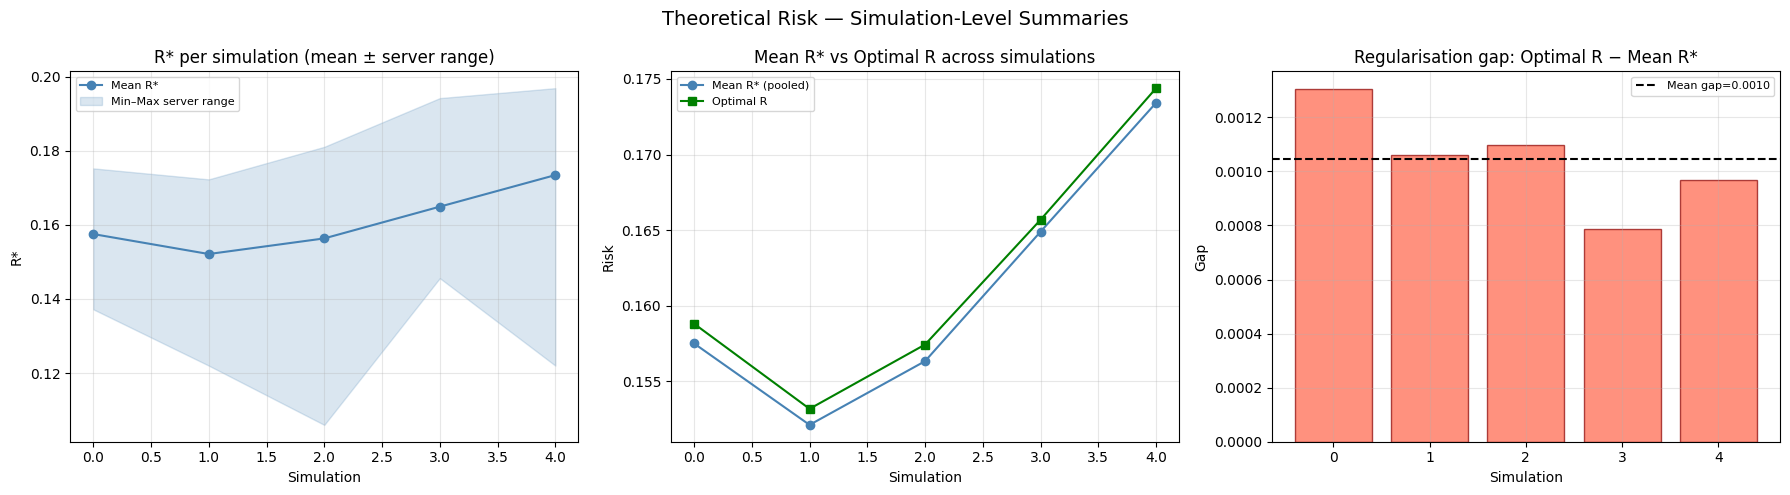

Saved: theory_sim_level.png


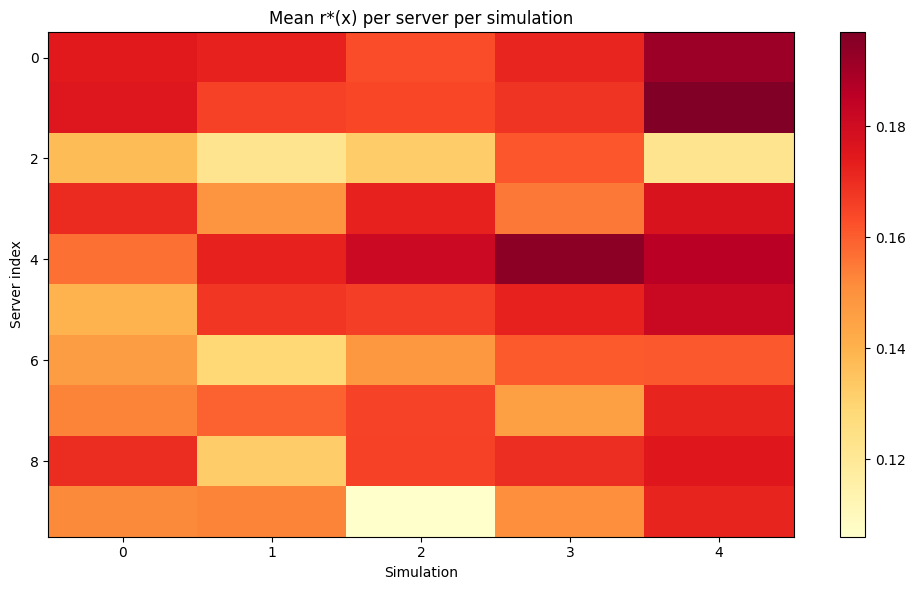

Saved: theory_rstar_per_server.png


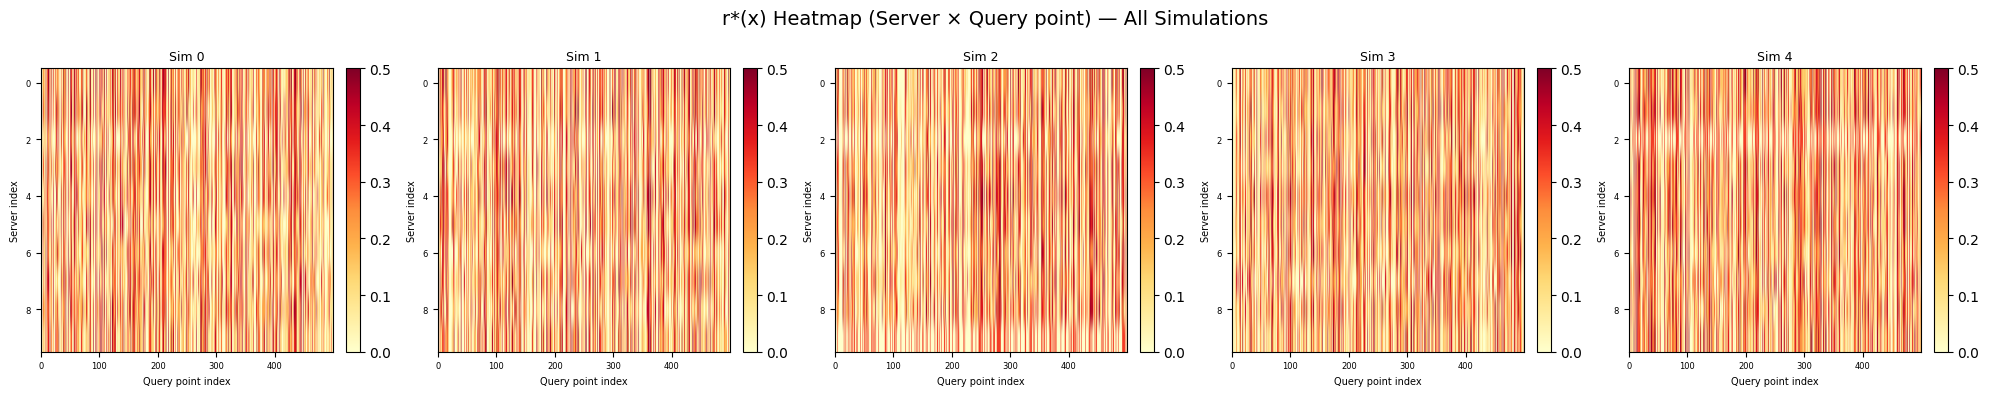

Saved: theory_rstar_heatmap.png


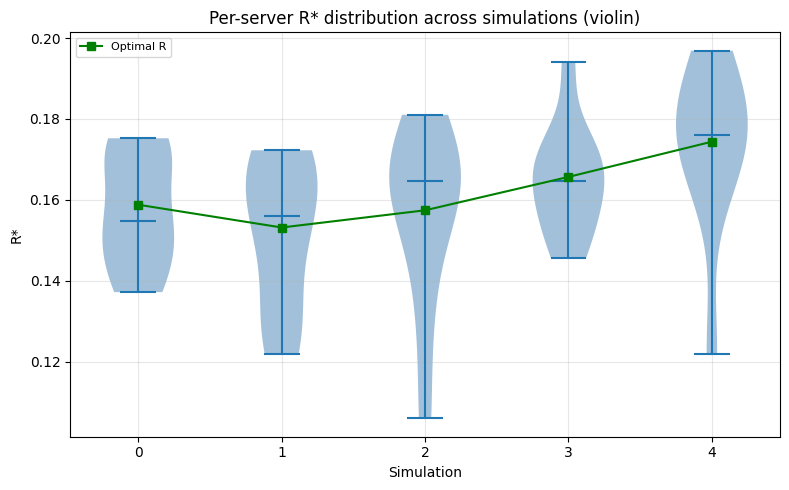

Saved: theory_rstar_violin.png


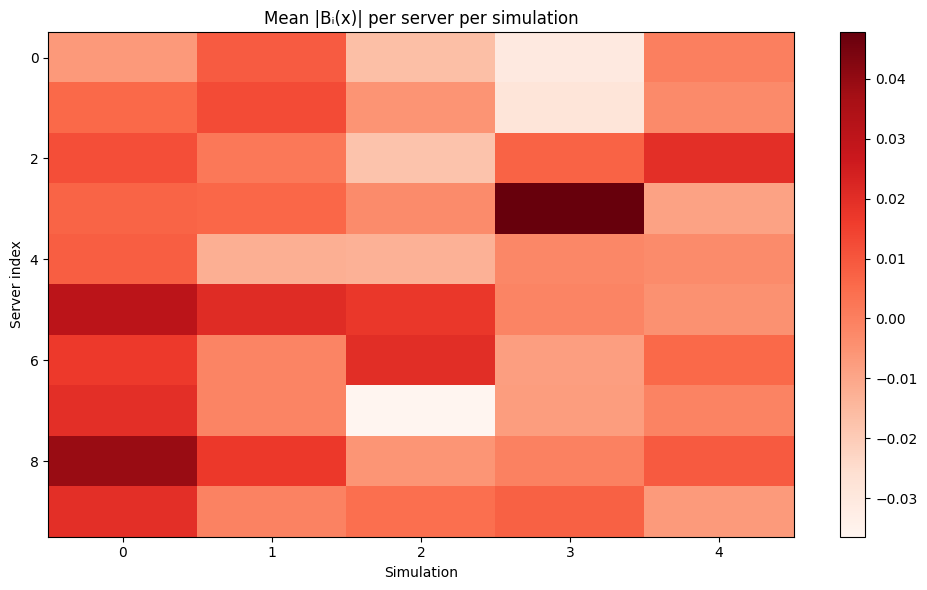

Saved: theory_bias_per_server.png


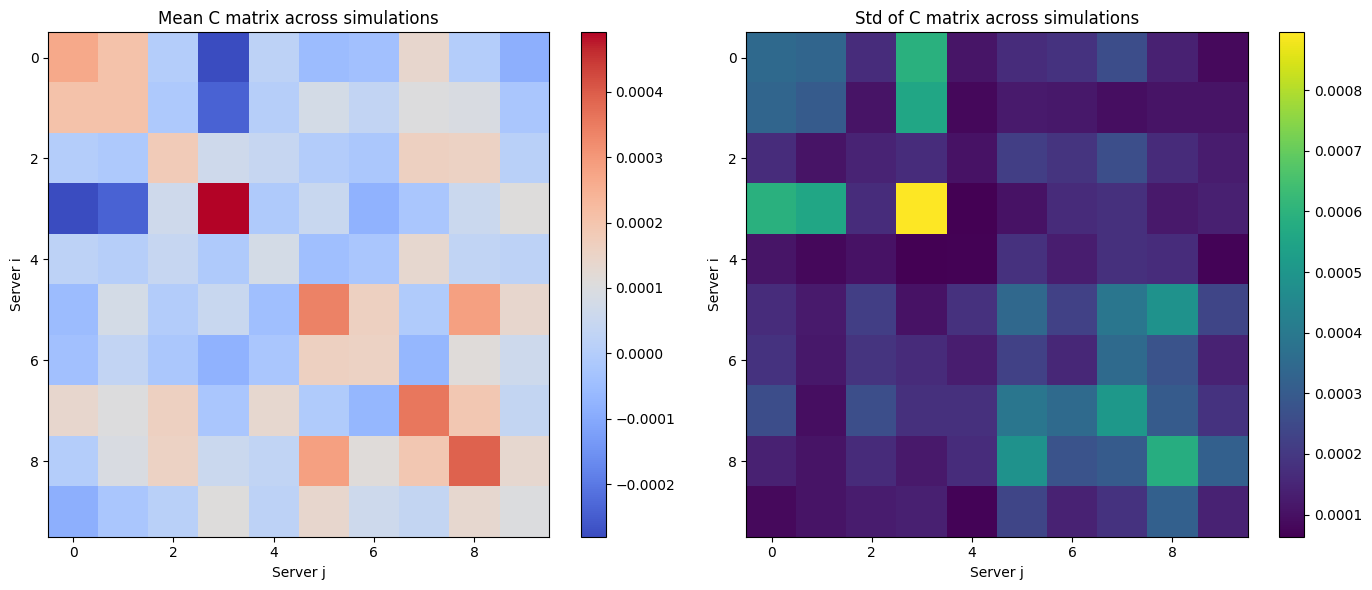

Saved: theory_C_matrices.png


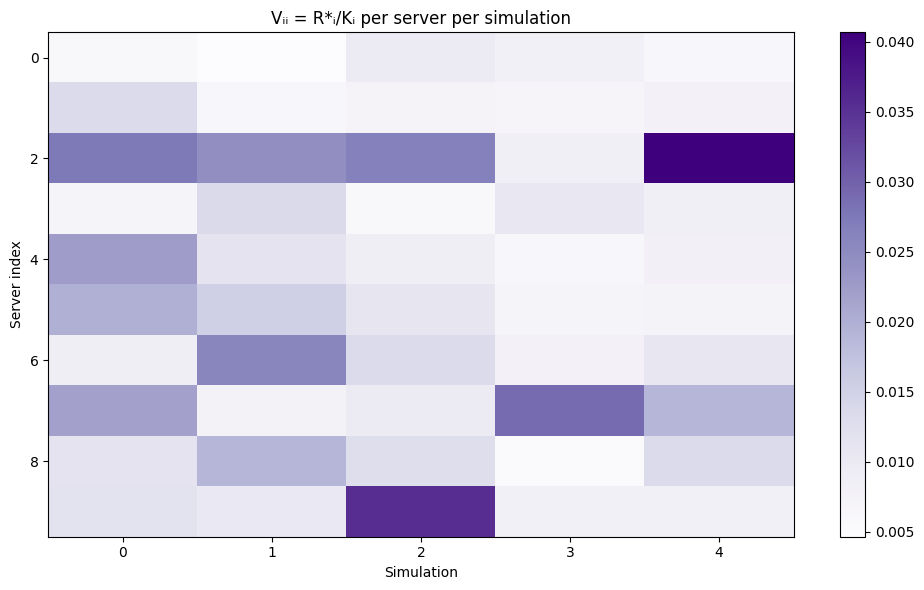

Saved: theory_V_diagonal.png


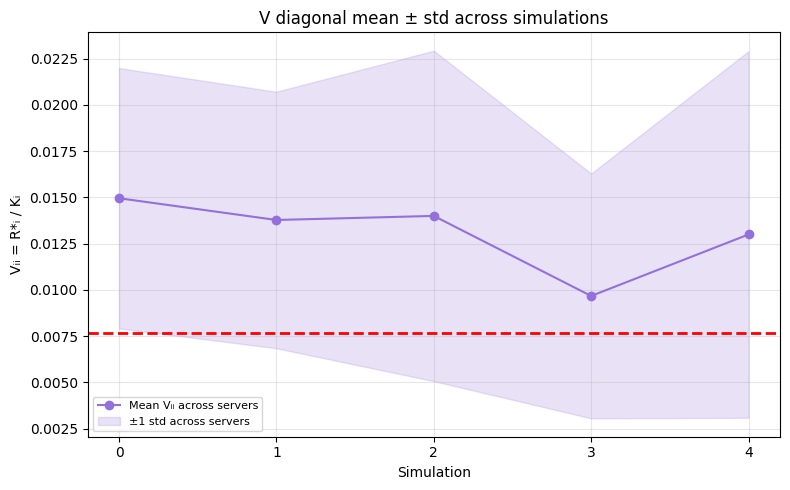

Saved: theory_V_trend.png


In [27]:
# %%
# ─────────────────────────────────────────────────────────────────────────────
# Visualize theoretical quantities across ALL simulations
# All arrays are reconstructed from results_df — no dependency on loop variables
# ─────────────────────────────────────────────────────────────────────────────

n_sims = len(results_df)
sim_ids = results_df['simulation'].values

# ── Reconstruct per-simulation arrays from results_df ─────────────────────────
# Each entry: list over simulations of ndarray (M, n_query) or (M,) or (M, M)
r_star_x_all = [np.array(results_df.loc[i, 'r_star_x_matrix']) for i in range(n_sims)]  # list of (M, n_query)
R_star_all   = [np.array(results_df.loc[i, 'r_star_per_server']) for i in range(n_sims)] # list of (M,)
bias_all     = [np.array(results_df.loc[i, 'bias_matrix'])       for i in range(n_sims)] # list of (M, n_query)
C_all        = [np.array(results_df.loc[i, 'C_matrix'])          for i in range(n_sims)] # list of (M, M)
V_all        = [np.array(results_df.loc[i, 'V_diag'])            for i in range(n_sims)] # list of (M,)

# Grid shape for per-simulation subplots
ncols = min(5, n_sims)
nrows = int(np.ceil(n_sims / ncols))

def hide_unused(axes_grid, n_used, nrows, ncols):
    for idx in range(n_used, nrows * ncols):
        axes_grid[idx // ncols][idx % ncols].set_visible(False)


# ═══════════════════════════════════════════════════════════════════════════════
# Figure 1 — Simulation-level scalar summary
# Plots: mean R* with server range band | mean R* vs optimal R | gap bar chart
# ═══════════════════════════════════════════════════════════════════════════════
fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))
fig1.suptitle('Theoretical Risk — Simulation-Level Summaries', fontsize=14)

ax = axes1[0]
ax.plot(sim_ids, results_df['mean_R_star'], marker='o', color='steelblue', label='Mean R*')
ax.fill_between(sim_ids, results_df['min_R_star'], results_df['max_R_star'],
                alpha=0.2, color='steelblue', label='Min–Max server range')
ax.set_title('R* per simulation (mean ± server range)')
ax.set_xlabel('Simulation')
ax.set_ylabel('R*')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes1[1]
ax.plot(sim_ids, results_df['mean_R_star'], marker='o', color='steelblue', label='Mean R* (pooled)')
ax.plot(sim_ids, results_df['optimal_R'],  marker='s', color='green',     label='Optimal R')
ax.set_title('Mean R* vs Optimal R across simulations')
ax.set_xlabel('Simulation')
ax.set_ylabel('Risk')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

ax = axes1[2]
gap = results_df['optimal_R'] - results_df['mean_R_star']
ax.bar(sim_ids, gap, color='tomato', alpha=0.7, edgecolor='darkred')
ax.axhline(gap.mean(), color='black', linestyle='--', label=f'Mean gap={gap.mean():.4f}')
ax.set_title('Regularisation gap: Optimal R − Mean R*')
ax.set_xlabel('Simulation')
ax.set_ylabel('Gap')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('theory_sim_level.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: theory_sim_level.png')


# ═══════════════════════════════════════════════════════════════════════════════
# Figure 2 — r*(x) boxplots per server, one subplot per simulation
# Each box = distribution of r*(x) over all query points for that server
# ═══════════════════════════════════════════════════════════════════════════════
# Figure 2 — replace boxplot with heatmap of median r*(x) per server per simulation
fig2, ax2 = plt.subplots(figsize=(max(10, n_sims * 0.8), max(6, len(R_star_all[0]) * 0.1)))
# Build matrix: rows=servers, cols=simulations
median_rstar_matrix = np.stack([r_mat.mean(axis=1) for r_mat in r_star_x_all], axis=1)  # (M, n_sims)
im = ax2.imshow(median_rstar_matrix, aspect='auto', cmap='YlOrRd')
plt.colorbar(im, ax=ax2)
ax2.set_title('Mean r*(x) per server per simulation')
ax2.set_xlabel('Simulation')
ax2.set_ylabel('Server index')
ax2.set_xticks(range(n_sims))
plt.tight_layout()
plt.savefig('theory_rstar_per_server.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: theory_rstar_per_server.png')


# ═══════════════════════════════════════════════════════════════════════════════
# Figure 3 — r*(x) heatmap (server × query point), one subplot per simulation
# Rows = servers, columns = query points; colour = r*(x) value
# ═══════════════════════════════════════════════════════════════════════════════
fig3, axes3 = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), squeeze=False)
fig3.suptitle('r*(x) Heatmap (Server × Query point) — All Simulations', fontsize=14)

for i, r_mat in enumerate(r_star_x_all):
    ax = axes3[i // ncols][i % ncols]
    im = ax.imshow(r_mat, aspect='auto', cmap='YlOrRd', vmin=0, vmax=0.5)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f'Sim {i}', fontsize=9)
    ax.set_xlabel('Query point index', fontsize=7)
    ax.set_ylabel('Server index', fontsize=7)
    ax.tick_params(labelsize=6)

hide_unused(axes3, n_sims, nrows, ncols)
plt.tight_layout()
plt.savefig('theory_rstar_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: theory_rstar_heatmap.png')


# ═══════════════════════════════════════════════════════════════════════════════
# Figure 4 — R* violin plot across all simulations
# One violin per simulation showing the full distribution of per-server R* values
# ═══════════════════════════════════════════════════════════════════════════════
fig4, ax4 = plt.subplots(figsize=(max(8, n_sims), 5))
violin_data = [r_vec for r_vec in R_star_all]   # list of (M,) arrays
parts = ax4.violinplot(violin_data, positions=sim_ids, showmedians=True, showextrema=True)
for pc in parts['bodies']:
    pc.set_facecolor('steelblue')
    pc.set_alpha(0.5)
ax4.plot(sim_ids, results_df['optimal_R'], marker='s', color='green', linewidth=1.5,
         label='Optimal R')
ax4.set_title('Per-server R* distribution across simulations (violin)')
ax4.set_xlabel('Simulation')
ax4.set_ylabel('R*')
ax4.set_xticks(sim_ids)
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('theory_rstar_violin.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: theory_rstar_violin.png')


# ═══════════════════════════════════════════════════════════════════════════════
# Figure 5 — Bias Bᵢ(x) boxplots per server, one subplot per simulation
# Each box = distribution of |Bᵢ(x)| over all query points for that server
# ═══════════════════════════════════════════════════════════════════════════════
# Figure 5 — heatmap of mean |Bᵢ(x)| per server per simulation
fig5, ax5 = plt.subplots(figsize=(max(10, n_sims * 0.8), max(6, len(bias_all[0]) * 0.1)))
mean_bias_matrix = np.stack([b_mat.mean(axis=1) for b_mat in bias_all], axis=1)  # (M, n_sims)
im = ax5.imshow(mean_bias_matrix, aspect='auto', cmap='Reds')
plt.colorbar(im, ax=ax5)
ax5.set_title('Mean |Bᵢ(x)| per server per simulation')
ax5.set_xlabel('Simulation')
ax5.set_ylabel('Server index')
ax5.set_xticks(range(n_sims))
plt.tight_layout()
plt.savefig('theory_bias_per_server.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: theory_bias_per_server.png')

# ═══════════════════════════════════════════════════════════════════════════════
# Figure 6 — C matrix heatmaps, one subplot per simulation
# ═══════════════════════════════════════════════════════════════════════════════
# Figure 6 — mean C matrix across simulations + std
C_stack = np.stack(C_all, axis=0)           # (n_sims, M, M)
C_mean  = C_stack.mean(axis=0)
C_std   = C_stack.std(axis=0)

fig6, axes6 = plt.subplots(1, 2, figsize=(14, 6))
im1 = axes6[0].imshow(C_mean, cmap='coolwarm', aspect='auto')
plt.colorbar(im1, ax=axes6[0])
axes6[0].set_title('Mean C matrix across simulations')
axes6[0].set_xlabel('Server j')
axes6[0].set_ylabel('Server i')

im2 = axes6[1].imshow(C_std, cmap='viridis', aspect='auto')
plt.colorbar(im2, ax=axes6[1])
axes6[1].set_title('Std of C matrix across simulations')
axes6[1].set_xlabel('Server j')
axes6[1].set_ylabel('Server i')

plt.tight_layout()
plt.savefig('theory_C_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: theory_C_matrices.png')


# ═══════════════════════════════════════════════════════════════════════════════
# Figure 7 — V diagonal (R*ᵢ/Kᵢ) bar charts per server, one subplot per simulation
# ═══════════════════════════════════════════════════════════════════════════════
# Figure 7 — heatmap of V diagonal across servers and simulations
fig7, ax7 = plt.subplots(figsize=(max(10, n_sims * 0.8), max(6, len(V_all[0]) * 0.1)))
V_matrix = np.stack(V_all, axis=1)          # (M, n_sims)
im = ax7.imshow(V_matrix, aspect='auto', cmap='Purples')
plt.colorbar(im, ax=ax7)
ax7.set_title('Vᵢᵢ = R*ᵢ/Kᵢ per server per simulation')
ax7.set_xlabel('Simulation')
ax7.set_ylabel('Server index')
ax7.set_xticks(range(n_sims))
plt.tight_layout()
plt.savefig('theory_V_diagonal.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: theory_V_diagonal.png')


# ═══════════════════════════════════════════════════════════════════════════════
# Figure 8 — V diagonal trend across simulations (mean ± std across servers)
# Shows how the variance term evolves from one simulation to the next
# ═══════════════════════════════════════════════════════════════════════════════
v_means = np.array([v.mean() for v in V_all])
v_stds  = np.array([v.std()  for v in V_all])

fig8, ax8 = plt.subplots(figsize=(max(8, n_sims), 5))
ax8.plot(sim_ids, v_means, marker='o', color='mediumpurple', label='Mean Vᵢᵢ across servers')
ax8.fill_between(sim_ids, v_means - v_stds, v_means + v_stds,
                 alpha=0.2, color='mediumpurple', label='±1 std across servers')
ax8.set_title('V diagonal mean ± std across simulations')
ax8.set_xlabel('Simulation')
ax8.set_ylabel('Vᵢᵢ = R*ᵢ / Kᵢ')
ax8.set_xticks(sim_ids)
ax8.legend(fontsize=8)
ax8.grid(True, alpha=0.3)
ax8.axhline(y=V_global_model, color='r', linestyle='--', linewidth=2, label=f'Global Model V: {V_global_model:.2f}')
plt.tight_layout()
plt.savefig('theory_V_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: theory_V_trend.png')